# Exploring Convolutional Layers Through Data and Experiments

In [2]:
%pip install numpy matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Dataset Exploration (EDA)

Provide a concise analysis including:

- Dataset size and class distribution

- Image dimensions and channels

- Examples of samples per class

- Any preprocessing needed (normalization, resizing)

The dataset picked is named CIFAR-10. This assignment requires an image-based dataset, with at least 2 clases and it should fit in memory of a standard laptop/cloud notebook. CIFAR-10 was chosen as it fits all of these criteria, it contains 60,000 color images across 10 balanced clases, and the whole thing is under 200MB. 

It's also a good pick for other reasons, for one, the images here have multiple colors, which adds another layer to the processing. Secondly, objects vary in pose, background and lighting, this variability will be useful. Lastly some of the objects, like cars, have multiple features which will allows us to train a satisfactory model.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

np.set_printoptions(precision=4, suppress=True)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

print("X_train_raw shape:", X_train_raw.shape)
print("y_train_raw shape:", y_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_test_raw shape:", y_test_raw.shape)

X_train_raw shape: (50000, 32, 32, 3)
y_train_raw shape: (50000, 1)
X_test_raw shape: (10000, 32, 32, 3)
y_test_raw shape: (10000, 1)


In [5]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution (training set):")
for cls_idx, count in zip(unique, counts):
    print(f"  {class_names[cls_idx]:<12} {count}")

Class distribution (training set):
  airplane     5000
  automobile   5000
  bird         5000
  cat          5000
  deer         5000
  dog          5000
  frog         5000
  horse        5000
  ship         5000
  truck        5000


The dataset is perfectly balanced: 5,000 images per class in the training set and 1,000 per class in the test set. This means we don't need to worry about class-imbalance techniques (like class weighting or oversampling) — accuracy alone is a reasonable metric here, unlike in imbalanced datasets where it can be misleading.

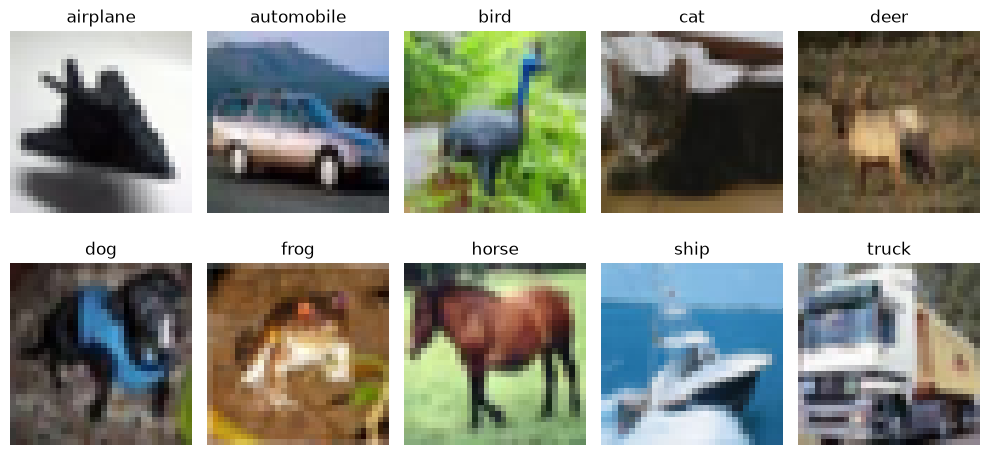

In [6]:
plt.figure(figsize=(10, 5))
for cls_idx in range(10):
    idx = np.where(y_train == cls_idx)[0][0]
    plt.subplot(2, 5, cls_idx + 1)
    plt.imshow(X_train_raw[idx])
    plt.title(class_names[cls_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
print("Image shape (single example):", X_train_raw[0].shape)
print("Pixel value range: min =", X_train_raw.min(), " max =", X_train_raw.max())
print("Data type:", X_train_raw.dtype)

Image shape (single example): (32, 32, 3)
Pixel value range: min = 0  max = 255
Data type: uint8


For our preprocessing then, we'll go through normalization. Each pixel in a CIFAR-10 image is currently stored as an integer from 0 to 255 (which is standard 8-bit color depth). Before training any neural network, we rescale these values to a range of 0 to 1 by dividing by 255.

This matters because neural networks learn through small, repeated weight updates. Large and inconsistent input values make those updates unstable and harder to tune, while small, consistent values (0–1) make optimization smoother and faster. This is a standard preprocessing step and does not change the information in the image, only its numeric scale.

In [8]:
# Convert integer pixels (0-255) into floats (0-1).
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

print("Before normalization - min/max:", X_train_raw.min(), X_train_raw.max())
print("After normalization  - min/max:", X_train.min(), X_train.max())
print("Shape (unchanged):", X_train.shape)

Before normalization - min/max: 0 255
After normalization  - min/max: 0.0 1.0
Shape (unchanged): (50000, 32, 32, 3)


Flattening: needed for the baseline, not for the CNN

A Dense (fully-connected) layer expects each example as a single flat row of numbers. Since each CIFAR-10 image is a 32×32×3 grid, we reshape it into one row of 3,072 values (32 × 32 × 3) for the baseline model in Section 2. Flattening discards the spatial layout of the image — the network no longer knows which pixels were originally next to each other.

Convolutional layers, by contrast, are specifically designed to operate on the image's original grid shape, since they rely on knowing which pixels are spatial neighbors. For that reason, we keep two versions of the data going forward:

X_train_flat / X_test_flat — flattened, used only for the baseline dense model.
X_train / X_test — original 3D shape, used later for the convolutional model.

In [9]:
# The CNN will use X_train / X_test directly (32, 32, 3) - no flattening needed.
# The baseline dense model needs a flat vector per image, so we make separate flattened copies.
X_train_flat = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test_flat = X_test.reshape(X_test.shape[0], 32 * 32 * 3)

print("CNN input shape:", X_train.shape)
print("Baseline (flattened) input shape:", X_train_flat.shape)

CNN input shape: (50000, 32, 32, 3)
Baseline (flattened) input shape: (50000, 3072)


# 2. Baseline Model (Non-Convolutional)

Implement a baseline neural network without convolutional layers

Report:

- Architecture

- Number of parameters

- Training and validation performance

- Observed limitations

This establishes a reference point.

Train/validation split

Before training, we set aside part of the training set as a validation set. This lets us monitor learning during training without touching the test set, which we save exclusively for a final, unbiased evaluation.

In [10]:
# Set aside the last 5,000 training examples as a validation set.
val_size = 5000

X_train_final = X_train_flat[:-val_size]
y_train_final = y_train[:-val_size]

X_val = X_train_flat[-val_size:]
y_val = y_train[-val_size:]

print("Training examples:", X_train_final.shape[0])
print("Validation examples:", X_val.shape[0])
print("Test examples:", X_test_flat.shape[0])

Training examples: 45000
Validation examples: 5000
Test examples: 10000


Baseline architecture: Flatten + Dense

This baseline establishes a reference point with no convolutional layers as required by the assignment. The input is the already flattened 3,072-value vector (32×32×3) from Section 1.

Architecture choices:

Two hidden layers (256, then 128 units), ReLU activation. ReLU is the standard default for hidden layers since it trains faster than sigmoid and avoids some of its optimization problems (as covered in the foundations notebook). We use more units than the MNIST example (25, 15) because CIFAR-10 images carry far more information per input (3,072 values vs. 784, and color/texture patterns instead of simple strokes), so the network needs more capacity to have any chance of separating 10 visually complex classes.
Output layer: 10 units, linear activation (logits). One unit per class, following the same multiclass pattern as the MNIST notebook.
Loss: sparse categorical crossentropy, from_logits=True. Labels are plain integers and computing softmax internally within the loss is more numerically stable than adding a separate softmax layer.

In [11]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

baseline_model = Sequential([
    Input(shape=(32 * 32 * 3,)),
    Dense(units=256, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="linear"),
])

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = baseline_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    verbose=1,
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3144 - loss: 1.9040 - val_accuracy: 0.3466 - val_loss: 1.8566
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3902 - loss: 1.7075 - val_accuracy: 0.3764 - val_loss: 1.7474
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4244 - loss: 1.6185 - val_accuracy: 0.3994 - val_loss: 1.6875
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4433 - loss: 1.5624 - val_accuracy: 0.4514 - val_loss: 1.5578
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4609 - loss: 1.5186 - val_accuracy: 0.4564 - val_loss: 1.5406
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4725 - loss: 1.4859 - val_accuracy: 0.4644 - val_loss: 1.5243
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4801 - loss: 1.4556 - val_accuracy: 0.4758 - val_loss: 1.4790
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4890 - loss: 1.4302 - val_accu

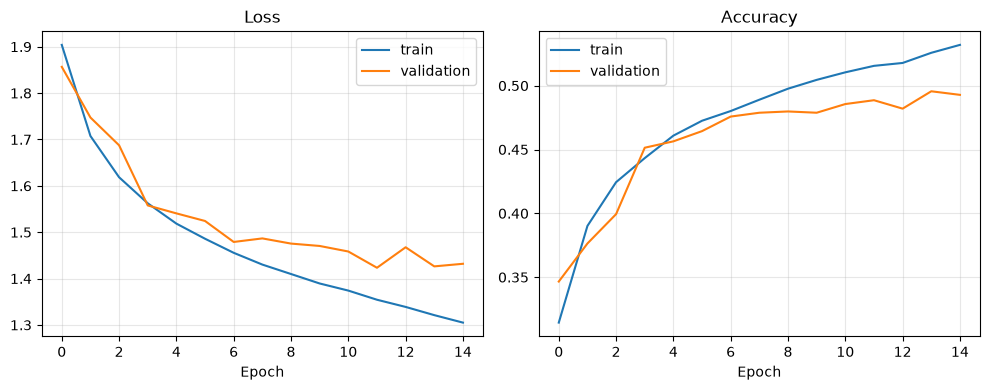

In [13]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
test_loss, test_accuracy = baseline_model.evaluate(X_test_flat, y_test, verbose=0)
print("Baseline test loss:", test_loss)
print("Baseline test accuracy:", test_accuracy)

Baseline test loss: 1.449215292930603
Baseline test accuracy: 0.4887000024318695


### Training and validation performance

Trained for 15 epochs, batch size 64, with a 45,000/5,000 train/validation split.

- Training accuracy climbed steadily to ~53% by epoch 15.
- Validation accuracy improved similarly for the first ~6–7 epochs, then plateaued around 47–49% and did not improve further, fluctuating slightly for the remaining epochs.
- Training loss decreased continuously throughout (1.89 → 1.31).
- Validation loss decreased for the first ~6–7 epochs (1.79 → ~1.45), then flattened and stopped improving, occasionally increasing slightly between epochs.
- **Final test accuracy: 47.9%** (test loss: 1.46), consistent with where validation performance settled.

### Observed limitations

The growing gap between training and validation curves after roughly epoch 6–7 is a sign of **overfitting**: the model continues improving on training data it has effectively memorized, while its ability to generalize to unseen data stalls.

This is expected behavior for a dense network on image data. Flattening the 32×32×3 image into a 3,072-value vector removes all spatial relationships between pixels — the network has no built-in notion that neighboring pixels are related, or that a pattern (e.g. an edge or a patch of fur) means the same thing regardless of where it appears in the image. As a result, the model must independently relearn similar patterns for every possible pixel position, which both wastes parameters (as reflected in the large first-layer weight count) and makes it easier to memorize specific training images rather than learn transferable visual features.

While 47.9% accuracy is well above the 10% expected from random guessing across 10 balanced classes, it falls well short of what a convolutional architecture is expected to achieve on CIFAR-10, since CNNs are specifically designed to exploit the spatial structure this baseline discards.

# 3. Convolutional Architecture Design

Overview: Two convolutional blocks (each: Conv → ReLU → MaxPool), followed by a Flatten step and two Dense layers for final classification. This is deliberately a small, simple design, in line with the assignment's guidance to avoid depth for its own sake.

Number of convolutional layers: 2. Deliberately small, this way there's enough neurons to build up from simple patterns to slightly more complex ones in a 32x32 image. More specifically, the first block can learn smiple local patterns like edges, color transitions and such, and the second block combines those into more complex ones like basic shapes or textures. This is enough for the type of images present on CIFAR-10, less layers likely wouldn't be ableto capture a lot and more layers risk overfitting on small images with a modest amount of training data.

Kernel sizes: 3x3. This is the standard size for modern CNN architectures, it is cheaper than a bigger one, since this has fewer total parameters than a 5x5 layer, this tends to help the model learn more expressive patterns. It is also adequate for the type of images being handled, 32x32 is rather small for an image, so 3x3 is well suited to capture finer details.

Filters: 32 in the first block, 64 in the second.
Filters determine how many distinct patterns each layer can learn to detect in parallel. The first block only needs to detect simple, low level pattern, as mentioned before, and there aren't many distinct types of these, so 32 filters are sufficient. The second block operates on the outputs of the first block, and is tasked with combining those simple patterns into a larger number of more complex ones (textures, partial object shapes) — this benefits from more filter slots, hence the increase to 64.

Stride and padding choices: Stride 1 so we don't skip any position and padding is the same so the width and height are unchanged, this way we lose no pixels in an already limited size image, agressively losing pixels near the borders across multiple layers might discard real information. Downsampling is not handled here, but by pooling instead, keeping the responsabilities of our architecture separated.

Activation functions: ReLu, standard for hidden layers, it's computationally cheap, and avoids issues other functions have like saturation or vanishing gradient. The final layer uses

Pooling strategy: 2x2 to half the image size while keeping the strongest activation in every region. By going from 32 -> 16 -> 8, we reduce the amount of computation needed in later layers.


In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

cnn_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(filters=32, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="linear"),
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_cnn = cnn_model.fit(
    X_train[:-val_size], y_train[:-val_size],
    validation_data=(X_train[-val_size:], y_train[-val_size:]),
    epochs=15,
    batch_size=64,
    verbose=1,
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.4800 - loss: 1.4603 - val_accuracy: 0.5964 - val_loss: 1.1660
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6162 - loss: 1.0939 - val_accuracy: 0.6370 - val_loss: 1.0365
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6689 - loss: 0.9461 - val_accuracy: 0.6886 - val_loss: 0.9116
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7050 - loss: 0.8446 - val_accuracy: 0.7150 - val_loss: 0.8543
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7334 - loss: 0.7634 - val_accuracy: 0.7114 - val_loss: 0.8666
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.7613 - loss: 0.6891 - val_accuracy: 0.7096 - val_loss: 0.8547
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7822 - loss: 0.6233 - val_accuracy: 0.7180 - val_loss: 0.8565
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8050 - loss: 0.5558 - 

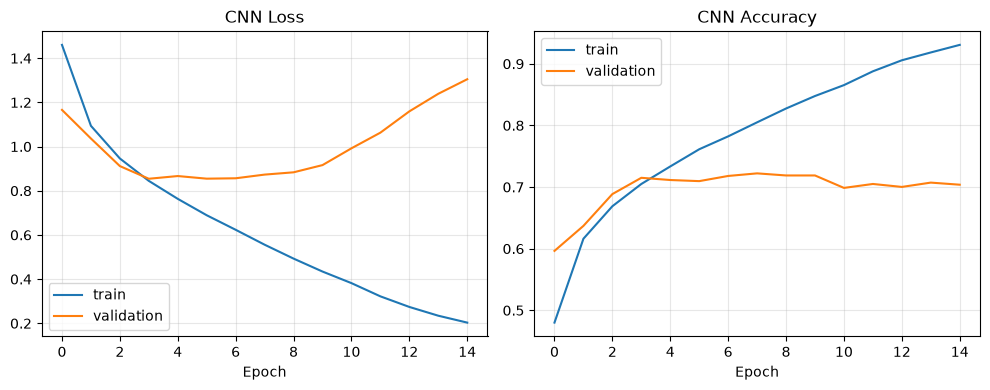

CNN test loss: 1.3531922101974487
CNN test accuracy: 0.6917999982833862


In [17]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["loss"], label="train")
plt.plot(history_cnn.history["val_loss"], label="validation")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["accuracy"], label="train")
plt.plot(history_cnn.history["val_accuracy"], label="validation")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print("CNN test loss:", test_loss_cnn)
print("CNN test accuracy:", test_accuracy_cnn)

## CNN Model: Results

### Parameters

Total parameters: 545,098, roughly 34% fewer than the baselines 820,874, despite
the CNN having more layers overall. This reflects convolutions core efficiency
advantage: a 3x3 filter has a small, fixed number of weights that get reused across
every position in the image, rather than requiring a unique weight for every
pixel-to-neuron connection as in a Dense layer.

### Training and validation performance

Trained for 15 epochs, same batch size (64) and train/validation split as the
baseline, for a fair comparison.

- Training accuracy climbed continuously to ~93% by epoch 15.
- Validation accuracy rose quickly for the first 3-4 epochs (up to ~71-72%), then
  plateaued and slightly degraded over the remaining epochs, ending around 70%.
- Training loss decreased continuously throughout (1.46 -> 0.20).
- Validation loss reached its lowest point around epoch 3-4 (~0.85), then steadily
  increased to 1.30 by epoch 15 even as training loss kept falling.
- **Final test accuracy: 69.2%** (test loss: 1.35).

### Comparison to baseline

| Metric | Baseline (Dense) | CNN |
|---|---|---|
| Test accuracy | 47.9% | 69.2% |
| Total parameters | 820,874 | 545,098 |
| Validation behavior | Plateaus ~epoch 6-7 | Peaks ~epoch 3-4, then degrades |

The CNN substantially outperforms the baseline (+21.3 points) while using about
34% fewer parameters, supporting the expectation that convolutional layers exploit
CIFAR-10's spatial structure far more effectively than a fully-connected network.

### Observed limitation: overfitting

The CNN seems to overfit more visibly, and earlier, than the baseline: validation
performance peaks around epoch 3-4 and then degrades while training performance
keeps improving. This means the model trained for the full 15 epochs is not
actually the best-performing version of itself — the version at epoch 3-4 would
generalize better. This is a natural byproduct of giving the model enough capacity
to substantially outperform the baseline; that same capacity makes it easier to
start memorizing training-specific details once the genuinely generalizable
patterns have already been learned. Techniques like early stopping, dropout, or
data augmentation would typically address this, though addressing it directly like this is
outside this assignment's scope.

# 4. Controlled Experiments on the Convolutional Layer

Convolutional Depth (1 vs 2 vs 3 layers)

For our experiment, we'll pick depth as the aspect to explore, this way we can isolate the effect of depth specifically. All three models share every other design choice mentioned earlier on task 3. Only the convolutional blocks changes.

In [18]:
cnn_1layer = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(filters=32, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="linear"),
])

cnn_1layer.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history_1layer = cnn_1layer.fit(
    X_train[:-val_size], y_train[:-val_size],
    validation_data=(X_train[-val_size:], y_train[-val_size:]),
    epochs=15,
    batch_size=64,
    verbose=1,
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.4232 - loss: 1.6049 - val_accuracy: 0.5456 - val_loss: 1.3232
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5475 - loss: 1.2815 - val_accuracy: 0.5696 - val_loss: 1.2283
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5892 - loss: 1.1660 - val_accuracy: 0.6030 - val_loss: 1.1460
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6244 - loss: 1.0790 - val_accuracy: 0.6184 - val_loss: 1.1058
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6482 - loss: 1.0112 - val_accuracy: 0.6174 - val_loss: 1.1113
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6688 - loss: 0.9539 - val_accuracy: 0.6220 - val_loss: 1.0786
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6884 - loss: 0.9002 - val_accuracy: 0.6364 - val_loss: 1.0538
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6986 - loss: 0.8617 - 

In [19]:
cnn_3layer = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(filters=32, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Conv2D(filters=128, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="linear"),
])

cnn_3layer.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history_3layer = cnn_3layer.fit(
    X_train[:-val_size], y_train[:-val_size],
    validation_data=(X_train[-val_size:], y_train[-val_size:]),
    epochs=15,
    batch_size=64,
    verbose=1,
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.4585 - loss: 1.4929 - val_accuracy: 0.5886 - val_loss: 1.1663
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6217 - loss: 1.0685 - val_accuracy: 0.6200 - val_loss: 1.0793
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.6856 - loss: 0.8985 - val_accuracy: 0.6748 - val_loss: 0.9199
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7229 - loss: 0.7904 - val_accuracy: 0.7176 - val_loss: 0.8072
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7583 - loss: 0.6917 - val_accuracy: 0.7294 - val_loss: 0.7685
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7873 - loss: 0.6117 - val_accuracy: 0.7334 - val_loss: 0.7813
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.8099 - loss: 0.5477 - val_accuracy: 0.7304 - val_loss: 0.7917
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8287 - loss: 0.4847 - 

In [20]:
test_loss_1, test_acc_1 = cnn_1layer.evaluate(X_test, y_test, verbose=0)
test_loss_2, test_acc_2 = cnn_model.evaluate(X_test, y_test, verbose=0)   # your existing 2-layer model
test_loss_3, test_acc_3 = cnn_3layer.evaluate(X_test, y_test, verbose=0)

print(f"1-layer CNN - test accuracy: {test_acc_1:.4f}  test loss: {test_loss_1:.4f}")
print(f"2-layer CNN - test accuracy: {test_acc_2:.4f}  test loss: {test_loss_2:.4f}")
print(f"3-layer CNN - test accuracy: {test_acc_3:.4f}  test loss: {test_loss_3:.4f}")

1-layer CNN - test accuracy: 0.6462  test loss: 1.0751
2-layer CNN - test accuracy: 0.6918  test loss: 1.3532
3-layer CNN - test accuracy: 0.7310  test loss: 1.2258


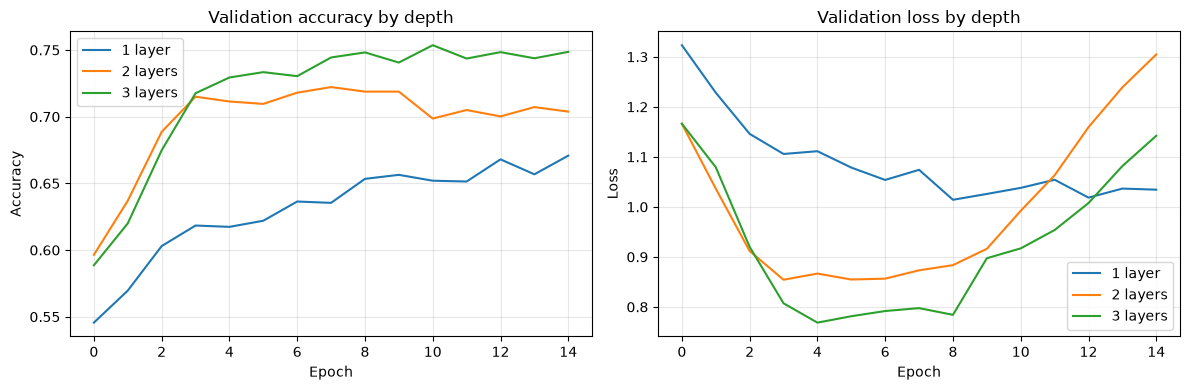

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_1layer.history["val_accuracy"], label="1 layer")
plt.plot(history_cnn.history["val_accuracy"], label="2 layers")
plt.plot(history_3layer.history["val_accuracy"], label="3 layers")
plt.title("Validation accuracy by depth")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_1layer.history["val_loss"], label="1 layer")
plt.plot(history_cnn.history["val_loss"], label="2 layers")
plt.plot(history_3layer.history["val_loss"], label="3 layers")
plt.title("Validation loss by depth")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Results


### Quantitative results

| Depth | Test accuracy | Test loss | Approx. time/epoch |
|---|---|---|---|
| 1 conv layer | 64.6% | 1.075 | ~15-16s |
| 2 conv layers | 69.2% | 1.353 | ~24-26s |
| 3 conv layers | 73.1% | 1.226 | ~33-38s |

### Qualitative observations

- **Accuracy improves with depth**: each additional convolutional
  block increased test accuracy, from 64.6% (1 layer) to 73.1% (3 layers),
  supporting the idea that deeper stacks build a richer hierarchy of features
  (edges -> textures/parts -> shapes) that a single shallow layer cannot capture
  on its own.
- **Loss did not improve monotonically**: the 2-layer model had the worst test
  loss of the three (1.353), despite outperforming the 1-layer model on accuracy.
  This indicates the 2-layer model became more confidently wrong on a subset of
  its mistakes, even while correctly classifying more examples overall — loss and
  accuracy do not always move together, since loss penalizes confident errors
  much more heavily than accuracy does.
- **Overfitting severity was not simply "more depth = more overfitting"**: the
  1-layer model showed the mildest overfitting (validation loss stayed nearly
  flat), the 2-layer model overfit most severely in loss terms (validation loss
  rose from ~0.85 to ~1.30), and the 3-layer model overfit somewhat less than the
  2-layer model despite having more parameters and more capacity, likely because
  its final feature maps are reduced to a very small 4x4 spatial size, which
  limits how much fine, memorizable detail remains by the final block.
- **Training cost scales with depth**: the 3-layer model took roughly 2-2.5x as
  long per epoch as the 1-layer model, for a real but comparatively smaller
  accuracy gain (2 -> 3 layers: +3.9 points) than the jump from 1 to 2 layers
  (+4.6 points), suggesting diminishing returns as depth increases on an image
  this small (32x32).

### Trade-offs: performance vs. complexity

Adding depth clearly improved this model's ability to classify CIFAR-10 images
correctly, consistent with the idea that deeper convolutional stacks build more
abstract, more useful visual features. However, this came at increasing
computational cost per epoch, and did not straightforwardly reduce overfitting or
improve loss — the deepest model was not the most numerically confident or
best-calibrated, even though it was the most accurate. This suggests that for a
small, 32x32 dataset like CIFAR-10, there is a practical ceiling to how much
benefit additional depth provides before diminishing returns and overfitting
become the dominant effects, and that accuracy alone can be a misleading measure
of the "best" model — loss and training/validation gap tell a more complete story.

# 5. Interpretation and Architectural Reasoning

**Why did convolutional layers outperform the baseline?**: As seen previously, the convolutional layers did in fact outperform the baseline. This happened even though the baseline model had more parameters than the convolutional model. This can be explained by the way our architecture works and how each model processes the information it receives. CNNs are better suited for image processing because they can capture spatial information and local patterns. In contrast, the baseline model processes each part of the image independently; when the input is flattened, the spatial relationships between neighboring pixels are lost. This limits the model's ability to learn patterns that depend on the local structure of the image. CNNs, on the other hand, can learn local patterns related to textures, colors, edges, and other visual features. As a result, as shown before, the baseline model is less accurate despite having more parameters.

**What inductive bias does convolution introduce?**: Inductive bias refers to the assumptions a model makes about the data. Convolution introduces two important assumptions. The first one is locality, meaning that relevant patterns are likely to appear in small, continuous regions of an image. The second is translation equivariance, meaning that the same pattern can be recognized regardless of where it appears in the image. In other words, a horse should still be recognized as a horse whether it appears on the left, right, top, or bottom of the image.

**In what type of problems would convolution not be appropriate?**: Convolution would not be appropriate for datasets where spatial relationships between neighboring values are not meaningful. A common example is tabular data, in this case the values in adjacent columns do not necessarily have a relation with one another. In such cases, the inductive bias introduced by convolution, that nearby values are related and that local patterns are important, would not accurately reflect the structure of the data and might even be detrimental in the learning process of the model.

# 6. Sagemaker

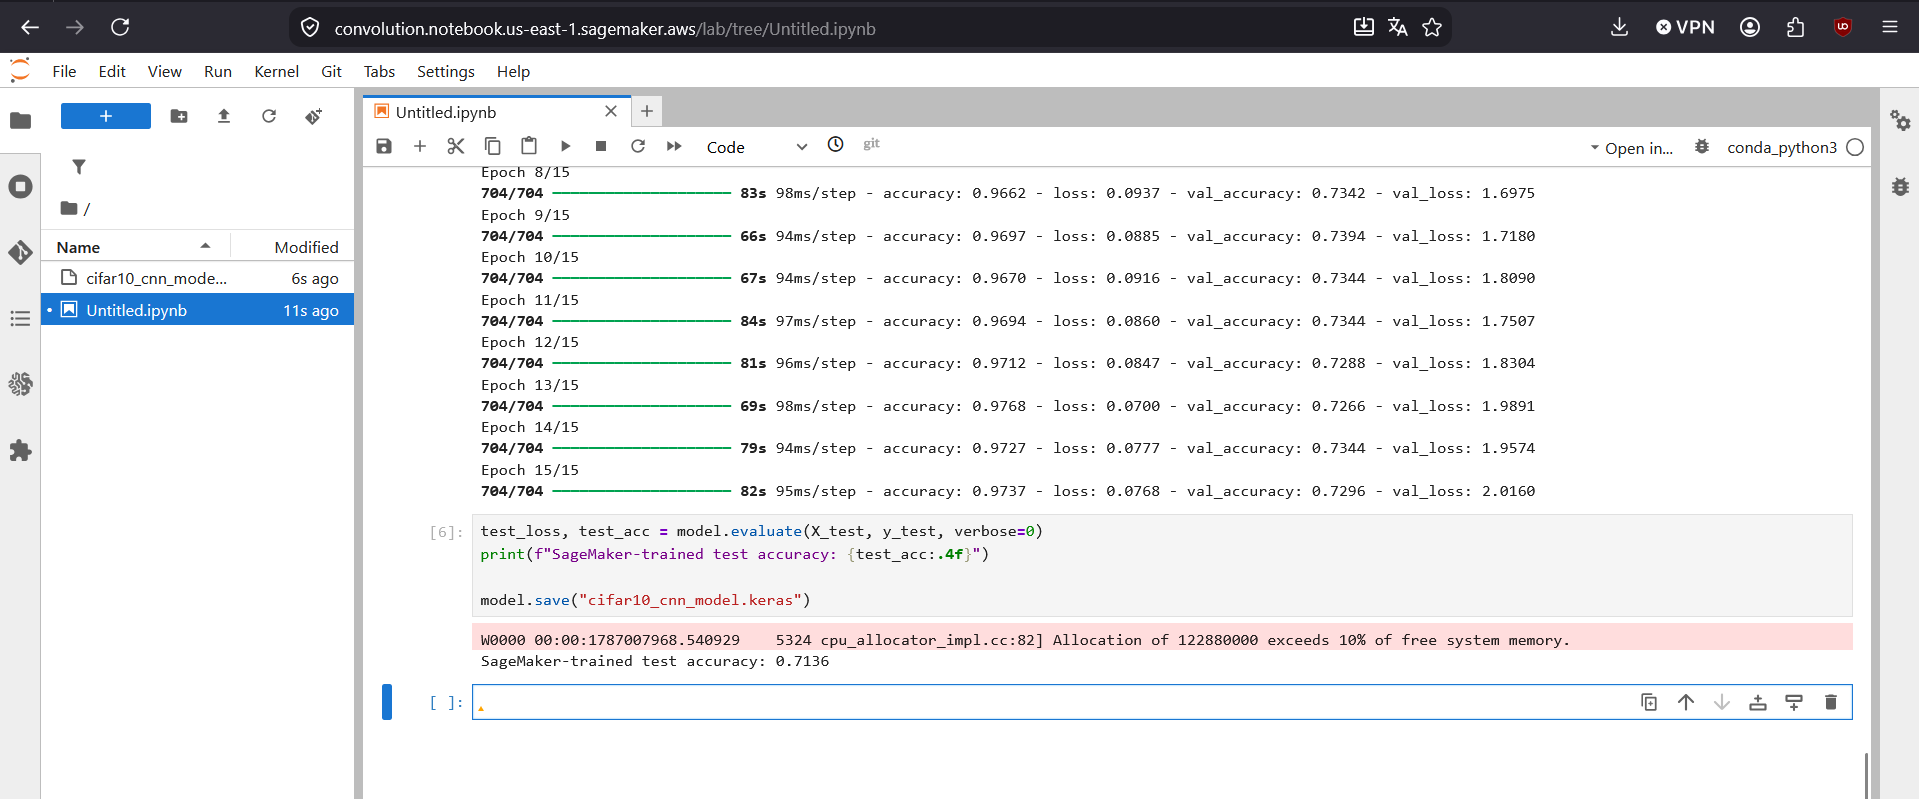